# City Weather Analysis

> **File:** `weather.ipynb`  
> **Purpose:** The retrieval and visualization of current weather conditions for over 500 cities across the globe

---

## Executive Summary

This notebook explores the relationship between geography and weather by pulling live conditions for over 500 cities worldwide via the OpenWeatherMap API and `citipy`. Four weather variables — **temperature, humidity, cloudiness, and wind speed** — are each plotted against both **latitude** and **longitude**, split by hemisphere, and analysed with regression. The central question is simple: does where a city sits on the globe predict what its weather looks like?

### What the Analysis Covers

| Section | Content |
|---------|---------|
| 1 | API data acquisition, city mapping, and CSV export/import |
| 2 | Global scatter plots (all cities) for each weather variable vs. latitude, plus a correlation matrix |
| 3 | Dataset split into Northern, Southern, Eastern, and Western hemispheres |
| 4 | Per-hemisphere scatter plots and linear regression: weather vs. **latitude** |
| 5 | Per-hemisphere scatter plots and linear regression: weather vs. **longitude** |

### Methodological Notes

- City coordinates are generated randomly via `citipy` to approximate a geographically representative sample; the actual city count varies each run depending on which coordinates resolve to a named city.
- Weather data is fetched live from OpenWeatherMap, so results reflect conditions at the time of the API call. Re-running the notebook on a different day will produce different absolute values, though the structural relationships described above are stable.
- The notebook's inline regressions use polynomial degrees of 1, 2, or 3 depending on the variable and hemisphere. The temperature–latitude relationship is explicitly noted as requiring a quadratic (degree-2) fit to be properly characterised.


### Key Findings

**Temperature is the only variable with a meaningful relationship to latitude — and that relationship is curved, not straight.**

A linear regression across all cities yields a correlation of only −0.53 between latitude and temperature, which looks modest. But temperature actually follows an inverted-U curve: it peaks near the equator and falls off toward both poles. Fitting a quadratic regression captures this shape and raises the correlation to **r = 0.886** — a strong fit by any standard. When split by hemisphere, the directionality flips as expected: in the Northern Hemisphere temperature falls as latitude increases (moving away from the equator), while in the Southern Hemisphere temperature rises as latitude increases (moving toward the equator). The pattern holds in both Eastern and Western hemispheres when a quadratic model is used.

**Humidity, cloudiness, and wind speed show no meaningful relationship to latitude or longitude.**

Across every hemisphere and both geographic axes, regression lines for these three variables are nearly flat. Humidity and cloudiness cluster loosely across all latitudes without any systematic trend. Wind speed similarly shows no geographic pattern at the scale of this analysis. The conclusion from the notebook's own discussions is consistent throughout: *latitude and longitude are weak predictors of humidity, cloudiness, and wind speed.*

**Longitude predicts nothing.**

Every longitude-based regression (Sections 5.1–5.4) produces a weak relationship for all four weather variables in all four hemispheres. This is the expected result — climate bands run east–west, not north–south, so longitude carries no systematic weather signal.

---


In [1]:
 #*******************************************************************************************
 #
 #  File Name:  weather.ipynb 
 #
 #  File Description:
 #      This Jupyter Notebook, weather.ipynb, is a Python script to visualize the 
 #      weather of over 500 cities of varying distances from the equator. The script 
 #      uses the citipy Python module and the openWeatherMap API to create a 
 #      representative model of weather across cities.
 #      
 #
 #  Date                Description                                 Programmer
 #  ---------------     ------------------------------------        ------------------
 #  08/12/2023          Initial Development                         Nicholas J. George
 #  03/04/2026          Upgraded Module                             Nicholas J. George
 #
 #******************************************************************************************/

import citipyx
import logx
import mapx
import matplotlibx
import pandasx

import warnings

import pandas as pd

from bokeh.util.warnings import BokehUserWarning


warnings.filterwarnings('ignore')

warnings.simplefilter(action = 'ignore', category = BokehUserWarning)


pd.options.mode.chained_assignment = None

In [2]:
CONSTANT_LOCAL_FILE_NAME = 'weather.ipynb'

In [3]:
logx.set_log_mode(False)

logx.set_image_mode(False)


logx.begin_program('weather')

# <br> **Section 1: Weather Data Acquisition**

## **1.1: City List**

In [4]:
cities_array = citipyx.rtn_city_names_array()

## **1.2: Weather Data from City List**

In [5]:
city_weather_df = citipyx.rtn_weather_df(cities_array)

logx.log_write_obj(city_weather_df)


CITY WEATHER DATA RETRIEVAL BEGINS...


Processing record #1 of set 1 for city, iqaluit.

Processing record #2 of set 1 for city, stanley.

Processing record #3 of set 1 for city, grytviken.

Processing record #4 of set 1 for city, quibala.

Processing record #5 of set 1 for city, bilibino.

Processing record #6 of set 1 for city, waitangi.

Processing record #7 of set 1 for city, isafjordur.

Processing record #8 of set 1 for city, steamboat springs.

Processing record #9 of set 1 for city, tura.

Processing record #10 of set 1 for city, yellowknife.

Processing record #11 of set 1 for city, port-aux-francais.

Processing record #12 of set 1 for city, aasiaat.

Processing record #13 of set 1 for city, flin flon.

Processing record #14 of set 1 for city, pisco.

Processing record #15 of set 1 for city, labrador city.

Processing record #16 of set 1 for city, talnakh.

Processing record #17 of set 1 for city, west island.

Processing record #18 of set 1 for city, margaret river.

Proce

## **1.3: Records Count**

In [6]:
rec_cnt_int = city_weather_df['city'].count()

logx.print_and_log_text \
    (f'There are {rec_cnt_int} records in the city weather dataframe.')

There are 707 records in the city weather dataframe.


## **1.4: Display City Weather Data Set**

In [7]:
pandasx.rtn_fmt_tbl(city_weather_df, 'Table: 1.4: City Weather Information')

city,latitude,longitude,temperature,humidity,cloudiness,wind_speed,country,date_time
fish,63.75,-68.51,-22.31,67,100,0.00,CA,2026-03-18 23:58:01
stanley,54.87,-1.70,43.63,92,75,2.30,GB,2026-03-18 23:57:53
grytviken,-54.28,-36.51,44.73,75,7,21.74,GS,2026-03-18 23:58:02
quibala,-10.73,14.98,67.51,90,35,1.05,AO,2026-03-18 23:58:03
bilibino,68.05,166.44,-8.14,89,5,6.96,RU,2026-03-18 23:58:04
waitangi,-43.95,-176.56,60.82,92,100,1.99,NZ,2026-03-18 23:58:04
isafjordur,66.08,-23.12,44.26,91,100,27.40,IS,2026-03-18 23:58:05
steamboat springs,40.48,-106.83,43.36,39,0,3.44,US,2026-03-18 23:58:05
tura,25.52,90.22,84.36,45,100,6.06,IN,2026-03-18 23:58:06
yellowknife,62.46,-114.35,-11.52,82,40,3.44,CA,2026-03-18 23:55:02


## **1.5: Display City Weather Locations**

In [8]:
mapx.set_tooltip_display(False)

mapx.disp_folium_circles_df(city_weather_df, 'Figure 1.5: City Weather Locations')

## **1.6: Export City Weather Data to CSV File**

In [9]:
city_weather_df.to_csv \
    (citipyx.config_dict['data']['datafile'],
     index_label = citipyx.config_dict['params']['index'])

## **1.7: Import City Weather Data from CSV File**

In [10]:
city_weather_import_df \
    = pd.read_csv \
        (citipyx.config_dict['data']['datafile'],
         index_col = citipyx.config_dict['params']['index'])

## **1.8: Display Imported City Weather Data Set**

In [11]:
pandasx.rtn_fmt_tbl(city_weather_import_df, 'Table: 1.8: Imported City Weather Information')

city,latitude,longitude,temperature,humidity,cloudiness,wind_speed,country,date_time
fish,63.75,-68.51,-22.31,67,100,0.00,CA,2026-03-18 23:58:01
stanley,54.87,-1.70,43.63,92,75,2.30,GB,2026-03-18 23:57:53
grytviken,-54.28,-36.51,44.73,75,7,21.74,GS,2026-03-18 23:58:02
quibala,-10.73,14.98,67.51,90,35,1.05,AO,2026-03-18 23:58:03
bilibino,68.05,166.44,-8.14,89,5,6.96,RU,2026-03-18 23:58:04
waitangi,-43.95,-176.56,60.82,92,100,1.99,NZ,2026-03-18 23:58:04
isafjordur,66.08,-23.12,44.26,91,100,27.40,IS,2026-03-18 23:58:05
steamboat springs,40.48,-106.83,43.36,39,0,3.44,US,2026-03-18 23:58:05
tura,25.52,90.22,84.36,45,100,6.06,IN,2026-03-18 23:58:06
yellowknife,62.46,-114.35,-11.52,82,40,3.44,CA,2026-03-18 23:55:02


## **1.9: Display Imported City Weather Locations**

In [12]:
mapx.disp_folium_circles_df(city_weather_import_df, 'Figure 1.9: Imported City Weather Locations')

# **Section 2: Scatter Plots**

## **2.1: Temperature vs. Latitude**

r-value:     0.8744
r-squared:   0.7646


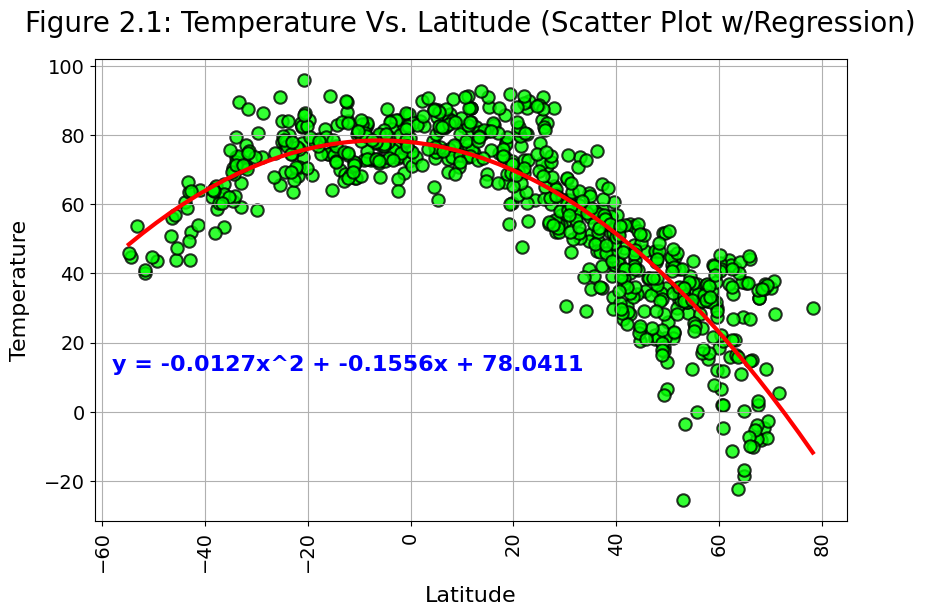

In [13]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Temperature')

matplotlibx.set_regr_degree(2)

matplotlibx.set_regr_eqn_coords(-58.0, 12.0)


matplotlibx.scatterplot_chart \
    ([city_weather_import_df['latitude'], 
      city_weather_import_df['temperature']],
     'Figure 2.1: Temperature Vs. Latitude (Scatter Plot w/Regression)')

## **Discussion about the linear relationship:** 
### Although this analysis uses linear regression, I notice that a relationship between the independent variable, latitude, and the dependent variable, temperature, exists but is not linear.  With quadratic regression, the correlation is 0.8858, a stark contrast to the correlation with linear regression of -0.5298. In practiice, analysts consider a 0.60-0.79 correlation to be strong.  

### What do these results mean?  The maximum temperature is hottest at the equator and cools down as we move towards either the North Pole or the South Pole.  On top of that, while correlation tells us that there is a relationship between two variables, it does not indicate cause and effect.

## **2.2: Humidity vs. Latitude**

r-value:     0.3767
r-squared:   0.1419


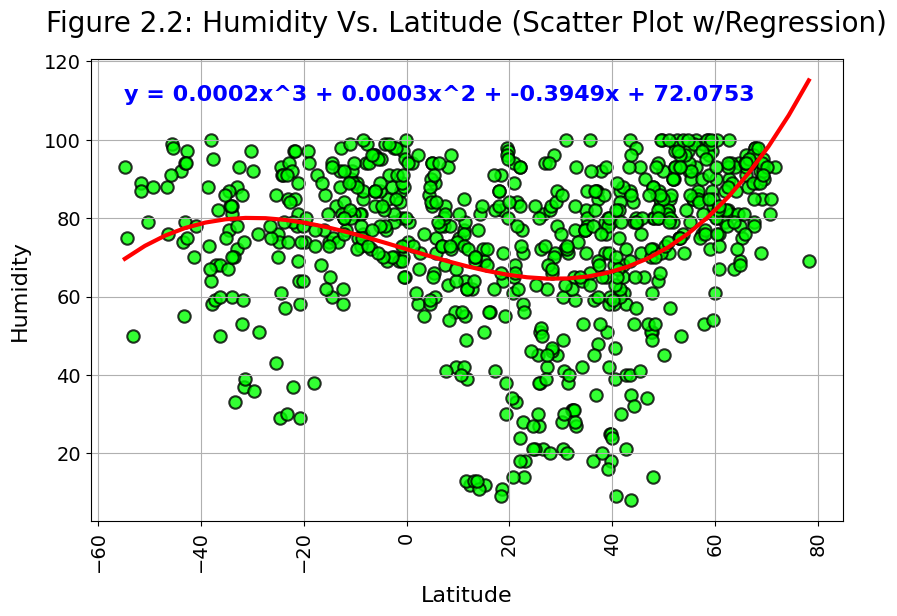

In [14]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Humidity')

matplotlibx.set_regr_degree(3)

matplotlibx.set_regr_eqn_coords(-55.0, 110.0)


matplotlibx.scatterplot_chart \
    ([city_weather_import_df['latitude'], 
      city_weather_import_df['humidity']],
     'Figure 2.2: Humidity Vs. Latitude (Scatter Plot w/Regression)')

## **2.3: Cloudiness vs. Latitude**

r-value:     0.2607
r-squared:   0.0679


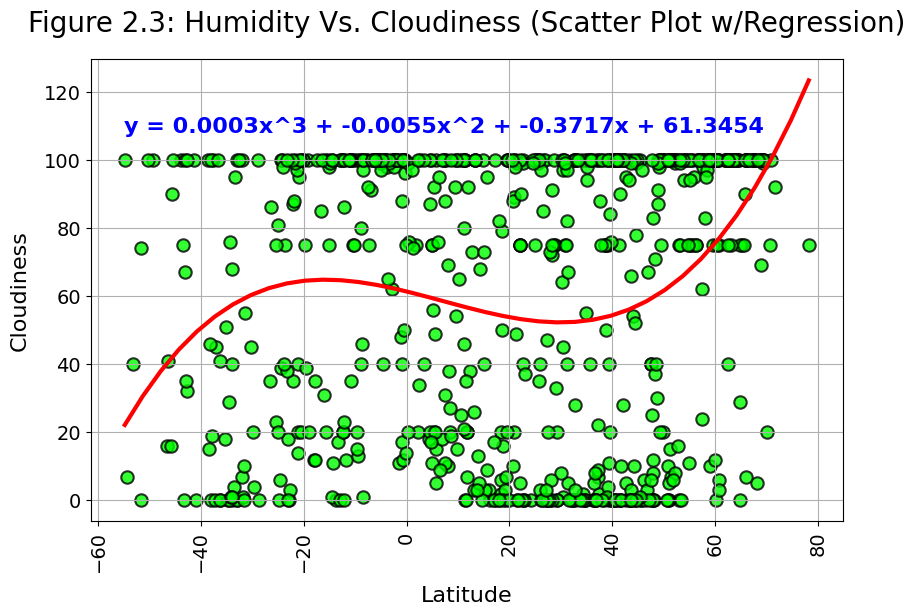

In [15]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Cloudiness')

matplotlibx.set_regr_degree(3)

matplotlibx.set_regr_eqn_coords(-55.0, 108.0)


matplotlibx.scatterplot_chart \
    ([city_weather_import_df['latitude'], 
      city_weather_import_df['cloudiness']],
     'Figure 2.3: Humidity Vs. Cloudiness (Scatter Plot w/Regression)')

## **2.4: Wind Speed vs. Latitude**

r-value:     0.2511
r-squared:   0.0631


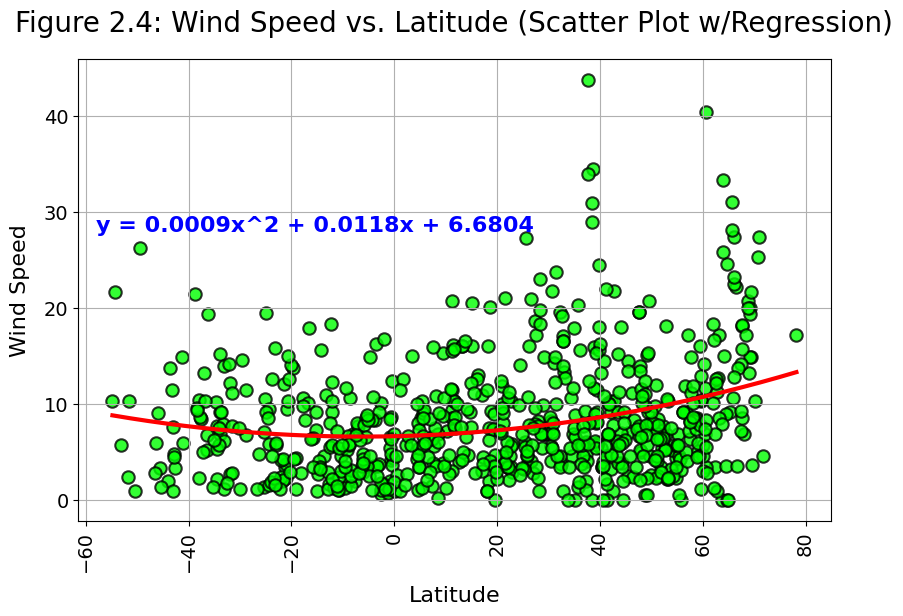

In [16]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Wind Speed')

matplotlibx.set_regr_degree(2)

matplotlibx.set_regr_eqn_coords(-58.0, 28.0)


matplotlibx.scatterplot_chart \
    ([city_weather_import_df['latitude'], 
      city_weather_import_df['wind_speed']],
     'Figure 2.4: Wind Speed vs. Latitude (Scatter Plot w/Regression)')

## **2.5: City Weather Data Set Correlation Matrix**

In [17]:
corr_df \
    = pd.DataFrame \
        ({'latitude': city_weather_import_df['latitude'], 
          'temperature': city_weather_import_df['temperature'], 
          'humidity': city_weather_import_df['humidity'],
          'cloudiness': city_weather_import_df['cloudiness'],
          'wind_speed': city_weather_import_df['wind_speed']}) \
        .corr()

pandasx.rtn_fmt_tbl(corr_df, 'Table 2.5: City Weather Correlation Matrix', hide_idx_bool = False)

,latitude,temperature,humidity,cloudiness,wind_speed
latitude,1.00,-0.70,0.02,0.12,0.20
temperature,-0.70,1.00,-0.25,-0.13,-0.08
humidity,0.02,-0.25,1.00,0.31,-0.13
cloudiness,0.12,-0.13,0.31,1.00,0.06
wind_speed,0.20,-0.08,-0.13,0.06,1.00


# **Section 3: City Weather Data By Hemisphere**

## **3.1: City Weather Data Set (Northern Hemisphere)**

In [18]:
northern_df = city_weather_import_df.loc[(city_weather_import_df['latitude'] >= 0.0), :]

logx.log_write_obj(northern_df)

### **Display City Weather Data Set (Northern Hemisphere)**

In [19]:
pandasx.rtn_fmt_tbl(northern_df, 'Table: 3.1: City Weather Data Set (Northern Hemisphere)')

city,latitude,longitude,temperature,humidity,cloudiness,wind_speed,country,date_time
fish,63.75,-68.51,-22.31,67,100,0.00,CA,2026-03-18 23:58:01
stanley,54.87,-1.70,43.63,92,75,2.30,GB,2026-03-18 23:57:53
bilibino,68.05,166.44,-8.14,89,5,6.96,RU,2026-03-18 23:58:04
isafjordur,66.08,-23.12,44.26,91,100,27.40,IS,2026-03-18 23:58:05
steamboat springs,40.48,-106.83,43.36,39,0,3.44,US,2026-03-18 23:58:05
tura,25.52,90.22,84.36,45,100,6.06,IN,2026-03-18 23:58:06
yellowknife,62.46,-114.35,-11.52,82,40,3.44,CA,2026-03-18 23:55:02
asian,68.71,-52.87,-4.63,92,100,20.71,GL,2026-03-18 23:58:08
flin flon,54.77,-101.86,12.24,97,100,4.41,CA,2026-03-18 23:58:08
labrador city,52.95,-66.91,-25.69,75,0,6.91,CA,2026-03-18 23:58:09


### **Display City Weather Locations (Northern Hemisphere)**

In [20]:
mapx.set_tooltip_display(True)

mapx.disp_folium_circles_df(northern_df, 'Figure 3.1: City Weather Locations (Northern Hemisphere)')

## **3.2: City Weather Data Set (Southern Hemisphere)**

In [21]:
southern_df = city_weather_import_df.loc[(city_weather_import_df['latitude'] < 0.0), :]

logx.log_write_obj(southern_df)

### **Display City Weather Data Set (Southern Hemisphere)**

In [22]:
pandasx.rtn_fmt_tbl(southern_df, 'Table: 3.2: City Weather Information (Southern Hemisphere)')

city,latitude,longitude,temperature,humidity,cloudiness,wind_speed,country,date_time
grytviken,-54.28,-36.51,44.73,75,7,21.74,GS,2026-03-18 23:58:02
quibala,-10.73,14.98,67.51,90,35,1.05,AO,2026-03-18 23:58:03
waitangi,-43.95,-176.56,60.82,92,100,1.99,NZ,2026-03-18 23:58:04
port-aux-francais,-49.35,70.22,43.56,88,100,26.28,TF,2026-03-18 23:58:07
pisco,-13.70,-76.22,69.85,83,0,4.61,PE,2026-03-18 23:58:09
west island,-12.16,96.82,84.18,84,86,9.22,CC,2026-03-18 23:58:10
margaret river,-33.95,115.07,79.45,60,68,15.21,AU,2026-03-18 23:58:11
it's good,-15.10,23.14,75.04,74,98,0.94,ZM,2026-03-18 23:58:14
marcona mines,-15.21,-75.11,64.31,81,100,7.34,PE,2026-03-18 23:58:15
vilhena,-12.74,-60.15,68.94,98,100,1.68,BR,2026-03-18 23:58:17


### **Display City Weather Locations (Southern Hemisphere)**

In [23]:
mapx.disp_folium_circles_df(southern_df, 'Figure 3.2: City Weather Locations (Southern Hemisphere)')

## **3.3: City Weather Data Set (Eastern Hemisphere)**

In [24]:
eastern_df = city_weather_import_df.loc[(city_weather_import_df['longitude'] >= 0.0), :]

logx.log_write_obj(eastern_df)

### **Display City Weather Data Set (Eastern Hemisphere)**

In [25]:
pandasx.rtn_fmt_tbl(eastern_df, 'Table: 3.3: City Weather Information (Eastern Hemisphere)')

city,latitude,longitude,temperature,humidity,cloudiness,wind_speed,country,date_time
quibala,-10.73,14.98,67.51,90,35,1.05,AO,2026-03-18 23:58:03
bilibino,68.05,166.44,-8.14,89,5,6.96,RU,2026-03-18 23:58:04
tura,25.52,90.22,84.36,45,100,6.06,IN,2026-03-18 23:58:06
port-aux-francais,-49.35,70.22,43.56,88,100,26.28,TF,2026-03-18 23:58:07
talnakh,69.49,88.40,-2.78,90,100,3.65,RU,2026-03-18 23:58:10
west island,-12.16,96.82,84.18,84,86,9.22,CC,2026-03-18 23:58:10
margaret river,-33.95,115.07,79.45,60,68,15.21,AU,2026-03-18 23:58:11
bad waldsee,47.92,9.77,34.86,88,83,7.29,DE,2026-03-18 23:58:12
lucky,66.42,112.40,14.86,88,100,22.24,RU,2026-03-18 23:58:12
dudinka,69.41,86.18,-7.71,92,99,14.88,RU,2026-03-18 23:58:13


### **Display City Weather Locations (Eastern Hemisphere)**

In [26]:
mapx.disp_folium_circles_df(eastern_df, 'Figure 3.3: City Weather Locations (Eastern Hemisphere)')

## **3.4: City Weather Data Set (Western Hemisphere)**

In [27]:
western_df = city_weather_import_df.loc[(city_weather_import_df['longitude'] < 0.0), :]

logx.log_write_obj(western_df)

### **Display City Weather Data Set (Western Hemisphere)**

In [28]:
pandasx.rtn_fmt_tbl(western_df, 'Table: 3.4: City Weather Information (Western Hemisphere)')

city,latitude,longitude,temperature,humidity,cloudiness,wind_speed,country,date_time
fish,63.75,-68.51,-22.31,67,100,0.00,CA,2026-03-18 23:58:01
stanley,54.87,-1.70,43.63,92,75,2.30,GB,2026-03-18 23:57:53
grytviken,-54.28,-36.51,44.73,75,7,21.74,GS,2026-03-18 23:58:02
waitangi,-43.95,-176.56,60.82,92,100,1.99,NZ,2026-03-18 23:58:04
isafjordur,66.08,-23.12,44.26,91,100,27.40,IS,2026-03-18 23:58:05
steamboat springs,40.48,-106.83,43.36,39,0,3.44,US,2026-03-18 23:58:05
yellowknife,62.46,-114.35,-11.52,82,40,3.44,CA,2026-03-18 23:55:02
asian,68.71,-52.87,-4.63,92,100,20.71,GL,2026-03-18 23:58:08
flin flon,54.77,-101.86,12.24,97,100,4.41,CA,2026-03-18 23:58:08
pisco,-13.70,-76.22,69.85,83,0,4.61,PE,2026-03-18 23:58:09


### **Display City Weather Locations (Western Hemisphere)**

In [29]:
mapx.disp_folium_circles_df(western_df, 'Figure 3.4: City Weather Locations (Western Hemisphere)')

# **Section 4: Scatter Plots w/Linear Regression by Latitude**

## **4.1: Temperature vs. Latitude**

### Display Temperature vs. Latitude (Northern Hemisphere)

r-value:     -0.8628
r-squared:   0.7444



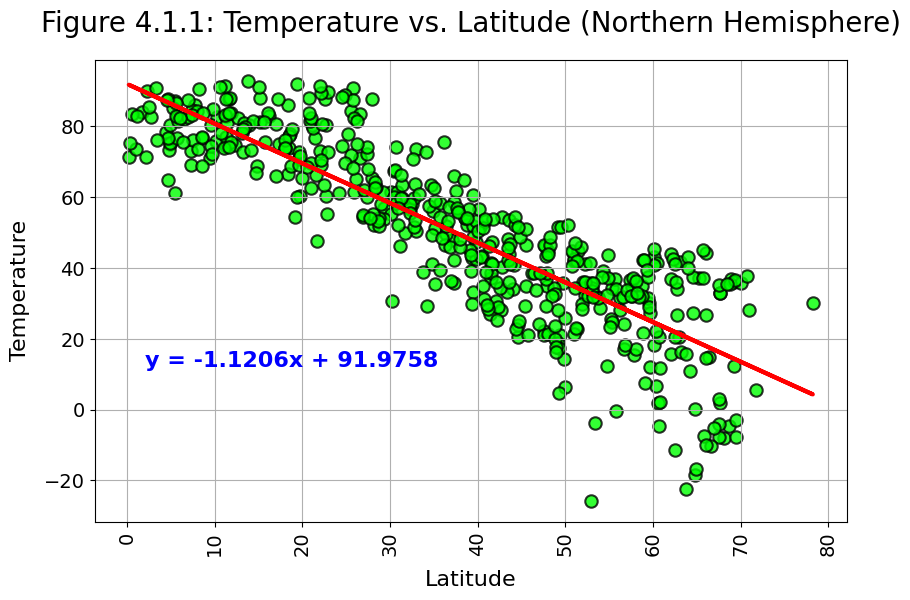

In [30]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Temperature')

matplotlibx.set_regr_degree(1)

matplotlibx.set_regr_eqn_coords(2.0, 12.0)


matplotlibx.scatterplot_chart \
    ([northern_df['latitude'], 
      northern_df['temperature']],
     'Figure 4.1.1: Temperature vs. Latitude (Northern Hemisphere)')

 ### Display Temperature vs. Latitude (Southern Hemisphere)

r-value:     0.6730
r-squared:   0.4530



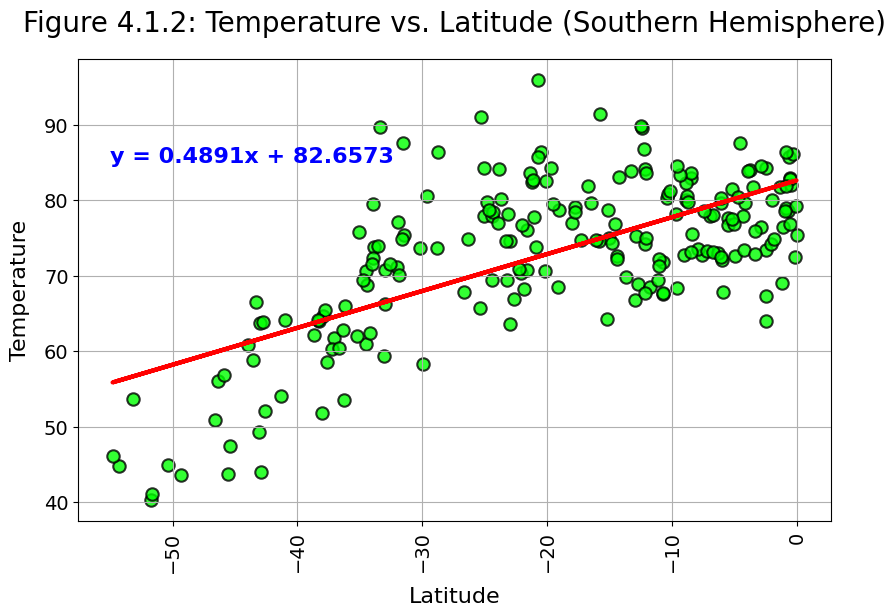

In [31]:
matplotlibx.set_regr_eqn_coords(-55.0, 85.0)

matplotlibx.scatterplot_chart \
    ([southern_df['latitude'], 
      southern_df['temperature']],
     'Figure 4.1.2: Temperature vs. Latitude (Southern Hemisphere)')

 ### Display Temperature vs. Latitude (Eastern Hemisphere)

r-value:     0.9021
r-squared:   0.8138


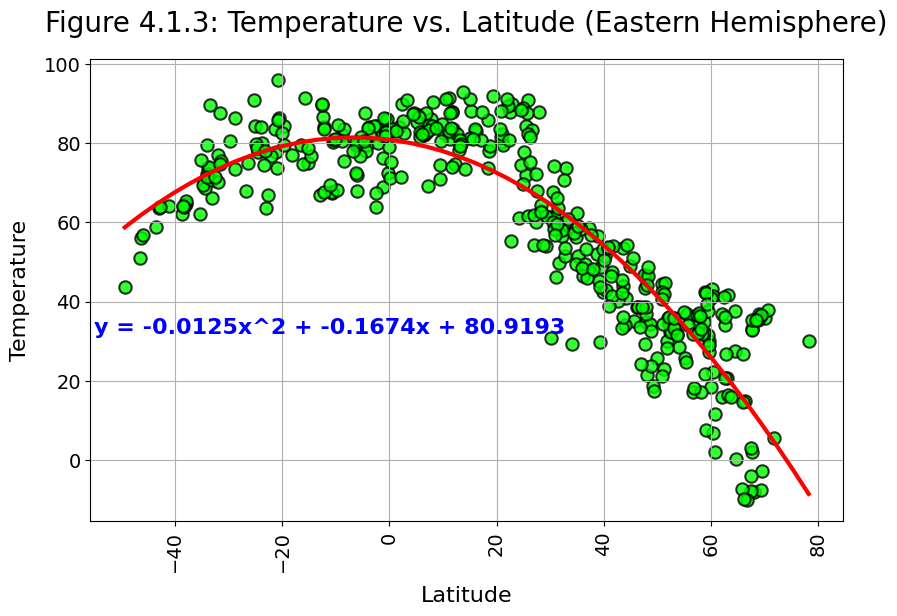

In [32]:
matplotlibx.set_regr_degree(2)

matplotlibx.set_regr_eqn_coords(-55.0, 32.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['latitude'], 
      eastern_df['temperature']],
     'Figure 4.1.3: Temperature vs. Latitude (Eastern Hemisphere)')

 ### Display Temperature vs. Latitude (Western Hemisphere)

r-value:     0.8581
r-squared:   0.7363


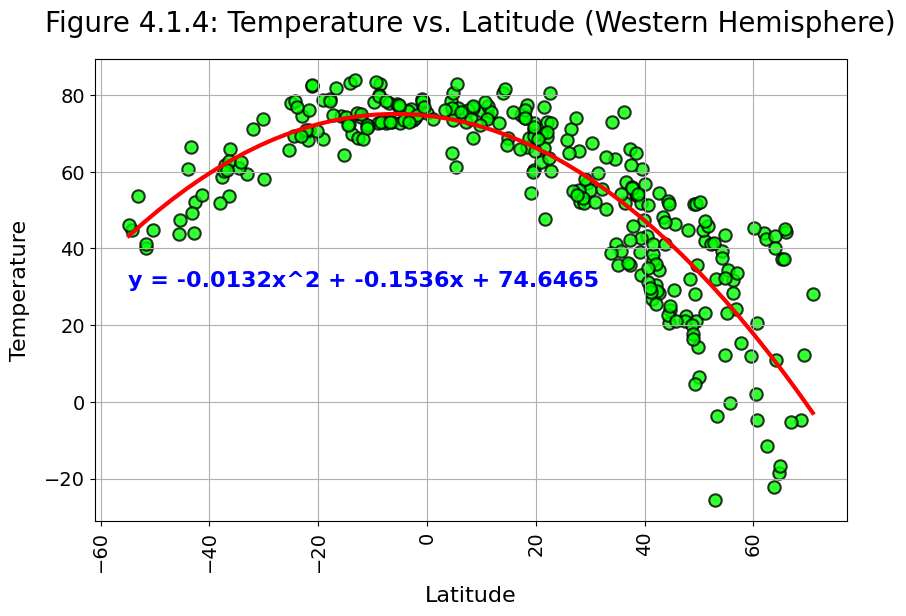

In [33]:
matplotlibx.set_regr_eqn_coords(-55.0, 30.0)

matplotlibx.scatterplot_chart \
    ([western_df['latitude'], 
      western_df['temperature']],
     'Figure 4.1.4: Temperature vs. Latitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### In the northern hemisphere, the latitude is negatively correlated with temperature; this negative correlation tells us that the two variables move in opposite directions: as latitude increases, the temperature drops, and vice versa.  In the southern hemisphere, the latitude is positively correlated with temperature: this positive correlation tells us that the two variables move in the same direction: as latitude increases, the temperature increases.  From the results of the quadratic regression, in both the eastern and western hemispheres, the latitude is positively correlated with temperature. 

### What do these results mean?  The maximum temperature is hottest at the equator and cools down as we move towards either the North Pole or the South Pole. On top of that, while correlation tells us that there is a relationship between two variables, it does not indicate cause and effect.

## **4.2: Humidity vs. Latitude**

### **Display Humidity vs. Latitude (Northern Hemisphere)**

r-value:     0.3254
r-squared:   0.1059



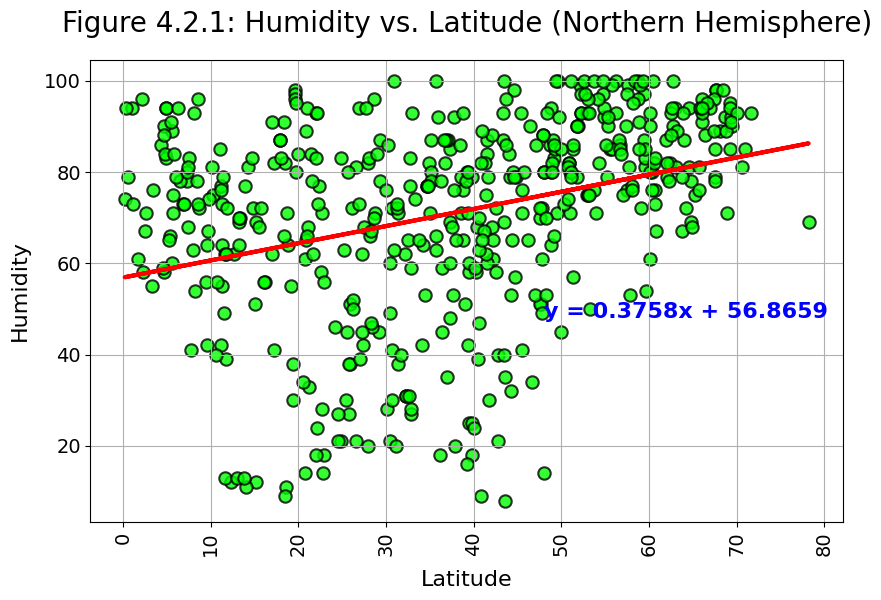

In [34]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Humidity')

matplotlibx.set_regr_degree(1)

matplotlibx.set_regr_eqn_coords(48.0, 48.0)


matplotlibx.scatterplot_chart \
    ([northern_df['latitude'], 
      northern_df['humidity']],
     'Figure 4.2.1: Humidity vs. Latitude (Northern Hemisphere)')

### **Display Humidity vs. Latitude (Southern Hemisphere)**

r-value:     0.1798
r-squared:   0.0323



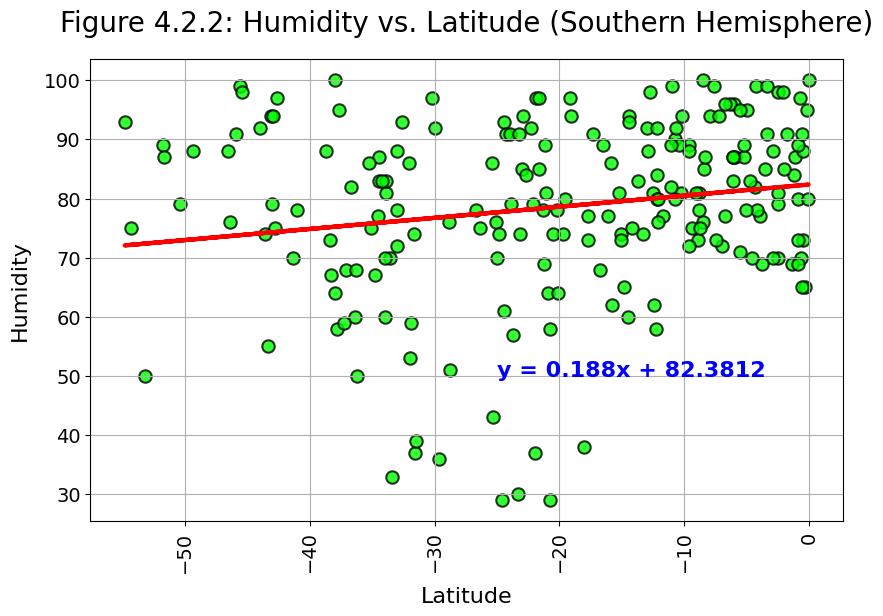

In [35]:
matplotlibx.set_regr_eqn_coords(-25.0, 50.0)

matplotlibx.scatterplot_chart \
    ([southern_df['latitude'], 
      southern_df['humidity']],
     'Figure 4.2.2: Humidity vs. Latitude (Southern Hemisphere)')

### **Display Humidity vs. Latitude (Eastern Hemisphere)**

r-value:     0.1455
r-squared:   0.0212



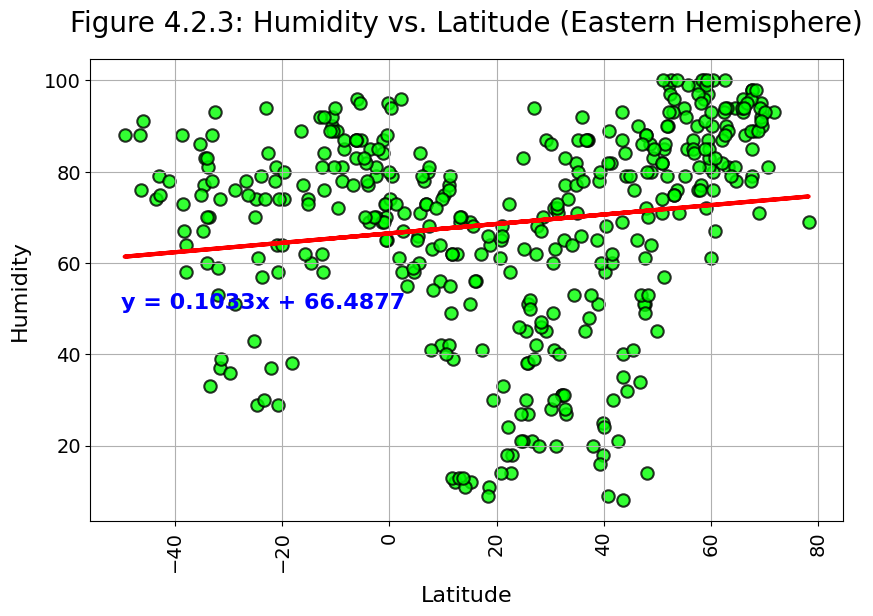

In [36]:
matplotlibx.set_regr_eqn_coords(-50.0, 50.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['latitude'], 
      eastern_df['humidity']],
     'Figure 4.2.3: Humidity vs. Latitude (Eastern Hemisphere)')

### **Display Humidity vs. Latitude (Western Hemisphere)**

r-value:     -0.1710
r-squared:   0.0292



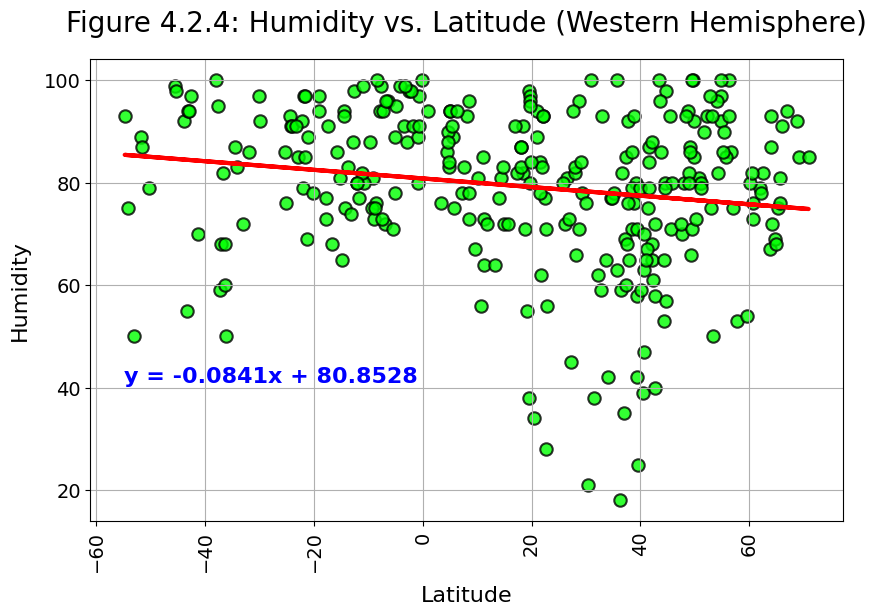

In [37]:
matplotlibx.set_regr_eqn_coords(-55.0, 41.0)

matplotlibx.scatterplot_chart \
    ([western_df['latitude'], 
      western_df['humidity']],
     'Figure 4.2.4: Humidity vs. Latitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### According to these scatter plots and regression lines, there is a very weak relationship relationship between latitude and humidity in any hemisphere.

## **4.3: Cloudiness vs. Latitude**

### **Display Cloudiness vs. Latitude (Northern Hemisphere)**

r-value:     0.2372
r-squared:   0.0563



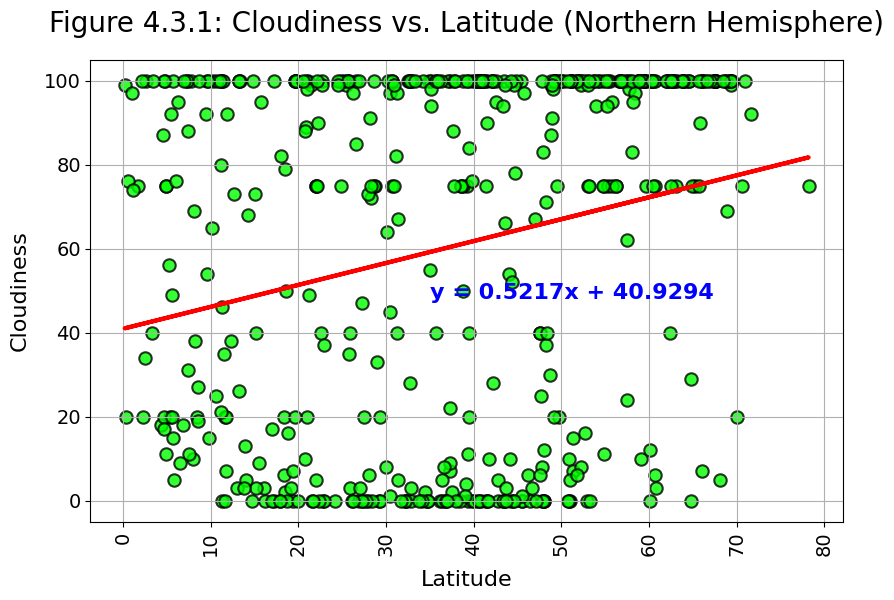

In [38]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Cloudiness')

matplotlibx.set_regr_eqn_coords(35.0, 48.0)


matplotlibx.scatterplot_chart \
    ([northern_df['latitude'], 
      northern_df['cloudiness']],
     'Figure 4.3.1: Cloudiness vs. Latitude (Northern Hemisphere)')

### **Display Cloudiness vs. Latitude (Southern Hemisphere)**

r-value:     0.3276
r-squared:   0.1073



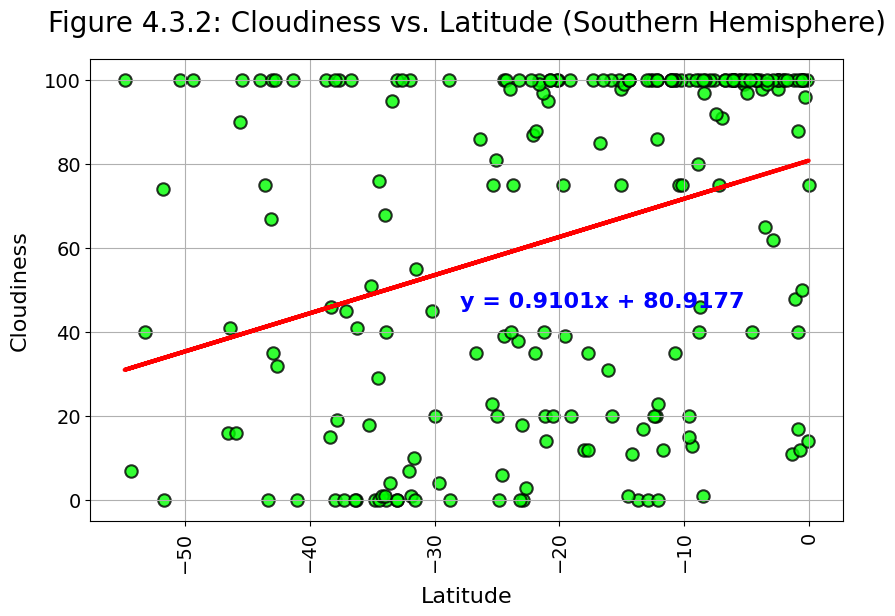

In [39]:
matplotlibx.set_regr_eqn_coords(-28.0, 46.0)

matplotlibx.scatterplot_chart \
    ([southern_df['latitude'], 
      southern_df['cloudiness']],
     'Figure 4.3.2: Cloudiness vs. Latitude (Southern Hemisphere)')

### **Display Cloudiness vs. Latitude (Eastern Hemisphere)**

r-value:     0.1688
r-squared:   0.0285



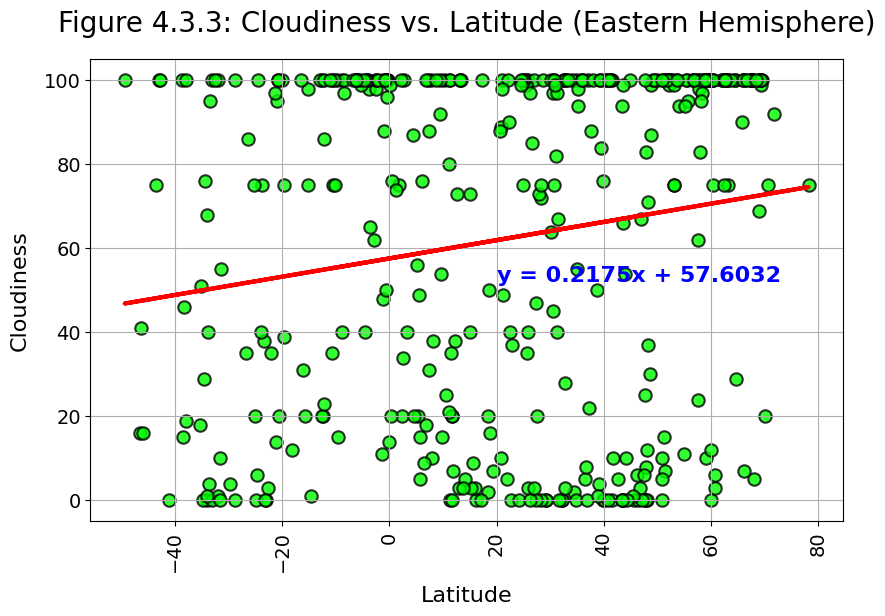

In [40]:
matplotlibx.set_regr_eqn_coords(20.0, 52.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['latitude'], 
      eastern_df['cloudiness']],
     'Figure 4.3.3: Cloudiness vs. Latitude (Eastern Hemisphere)')

### **Display Cloudiness vs. Latitude (Western Hemisphere)**

r-value:     0.0534
r-squared:   0.0029



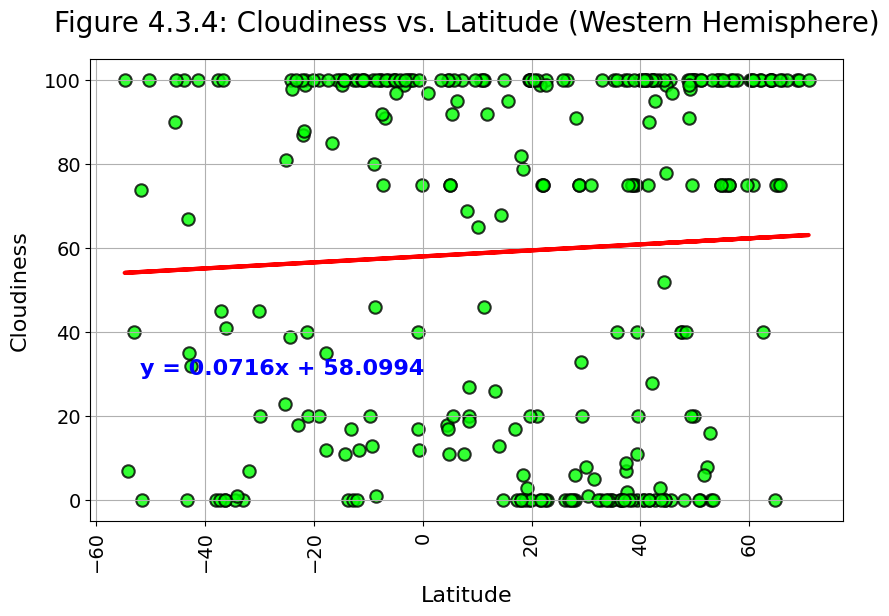

In [41]:
matplotlibx.set_regr_eqn_coords(-52.0, 30.0)

matplotlibx.scatterplot_chart \
    ([western_df['latitude'], 
      western_df['cloudiness']],
     'Figure 4.3.4: Cloudiness vs. Latitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### According to these scatter plots and regression lines, there is a very weak relationship relationship between latitude and cloudiness in any hemisphere.

## **4.4: Wind Speed vs. Latitude**

### **Display Wind Speed vs. Latitude (Northern Hemisphere)**

r-value:     0.2488
r-squared:   0.0619



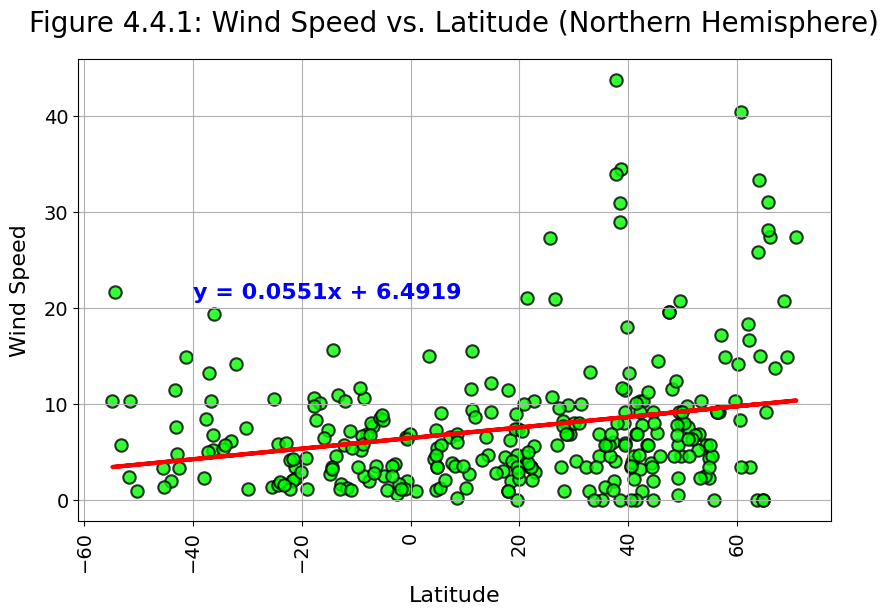

In [42]:
matplotlibx.set_scatterplot_chart_xylabels('Latitude', 'Wind Speed')

matplotlibx.set_regr_eqn_coords(-40.0, 21.0)


matplotlibx.scatterplot_chart \
    ([western_df['latitude'], 
      western_df['wind_speed']],
     'Figure 4.4.1: Wind Speed vs. Latitude (Northern Hemisphere)')

### **Display Wind Speed vs. Latitude (Southern Hemisphere)**

r-value:     -0.2269
r-squared:   0.0515



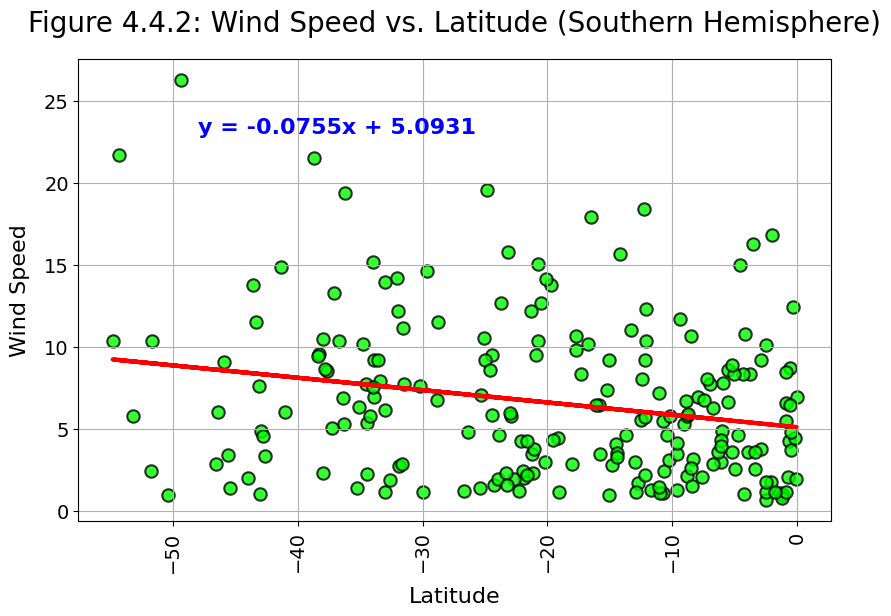

In [43]:
matplotlibx.set_regr_eqn_coords(-48.0, 23.0)

matplotlibx.scatterplot_chart \
    ([southern_df['latitude'], 
      southern_df['wind_speed']],
     'Figure 4.4.2: Wind Speed vs. Latitude (Southern Hemisphere)')

### **Display Wind Speed vs. Latitude (Eastern Hemisphere)**

r-value:     0.1505
r-squared:   0.0227



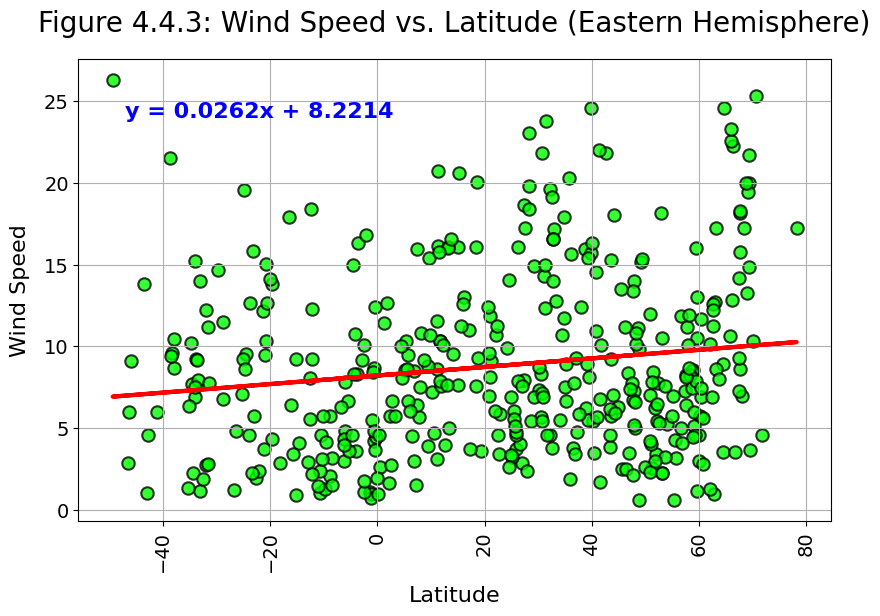

In [44]:
matplotlibx.set_regr_eqn_coords(-47.0, 24.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['latitude'], 
      eastern_df['wind_speed']],
     'Figure 4.4.3: Wind Speed vs. Latitude (Eastern Hemisphere)')

### **Display Wind Speed vs. Latitude (Western Hemisphere)**

r-value:     0.2488
r-squared:   0.0619



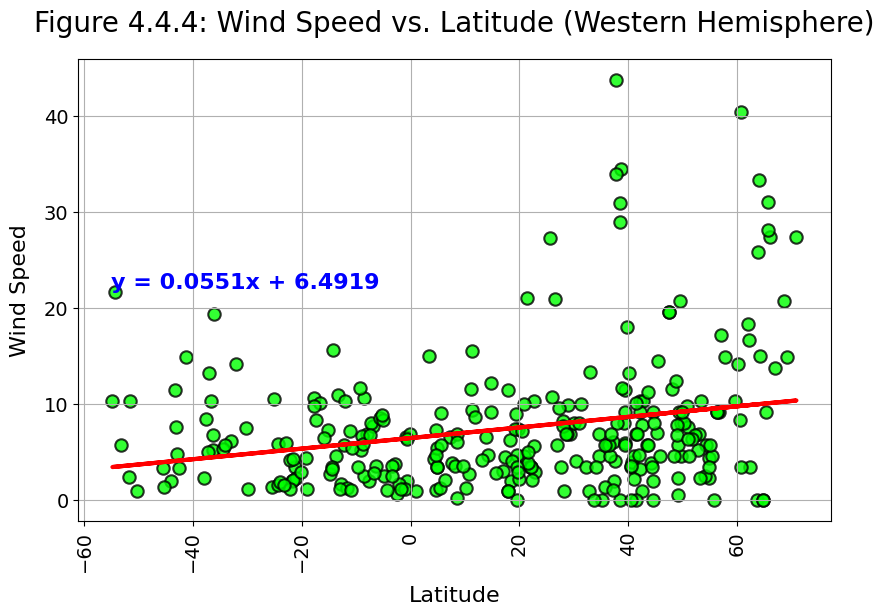

In [45]:
matplotlibx.set_regr_eqn_coords(-55.0, 22.0)

matplotlibx.scatterplot_chart \
    ([western_df['latitude'], 
      western_df['wind_speed']],
     'Figure 4.4.4: Wind Speed vs. Latitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### According to these scatter plots and regression lines, there is a very weak relationship relationship between latitude and wind speed in any hemisphere.

# **Section 5: Scatter Plots w/Linear Regression by Longitude**

## **5.1: Temperature vs. Longitude**

### Display Temperature vs. Longitude (Northern Hemisphere)

r-value:     0.0830
r-squared:   0.0069



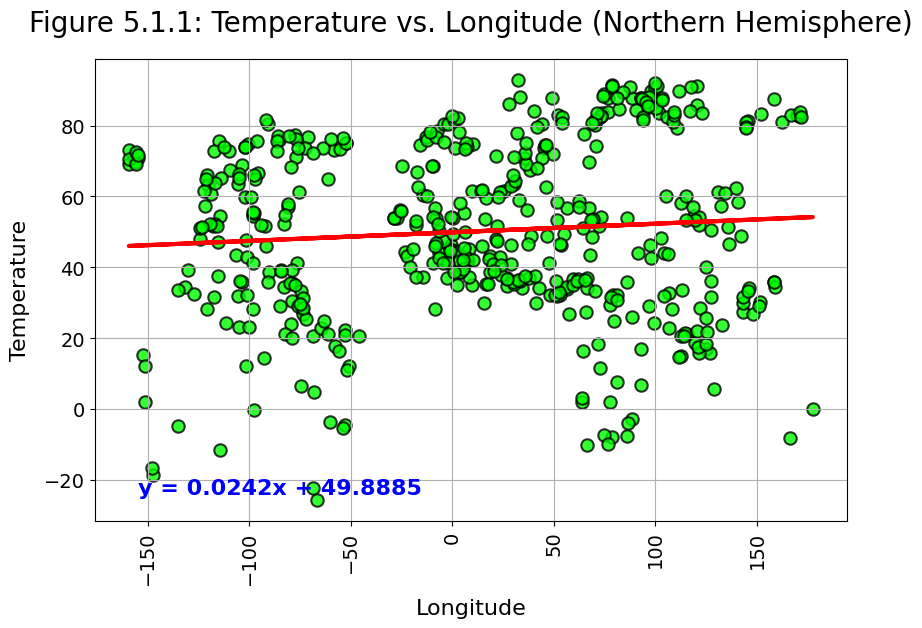

In [46]:
matplotlibx.set_scatterplot_chart_xylabels('Longitude', 'Temperature')

matplotlibx.set_regr_eqn_coords(-155.0, -24.0)


matplotlibx.scatterplot_chart \
    ([northern_df['longitude'], 
      northern_df['temperature']],
     'Figure 5.1.1: Temperature vs. Longitude (Northern Hemisphere)')

 ### Display Temperature vs. Longitude (Southern Hemisphere)

r-value:     0.2405
r-squared:   0.0578



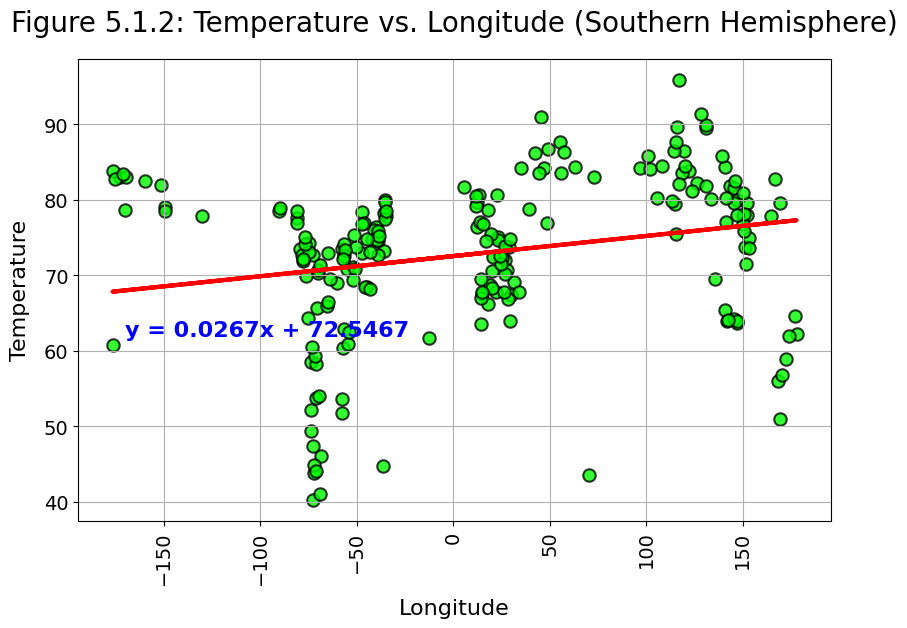

In [47]:
matplotlibx.set_regr_eqn_coords(-170.0, 62.0)

matplotlibx.scatterplot_chart \
    ([southern_df['longitude'], 
      southern_df['temperature']],
     'Figure 5.1.2: Temperature vs. Longitude (Southern Hemisphere)')

 ### Display Temperature vs. Longitude (Eastern Hemisphere)

r-value:     0.0562
r-squared:   0.0032



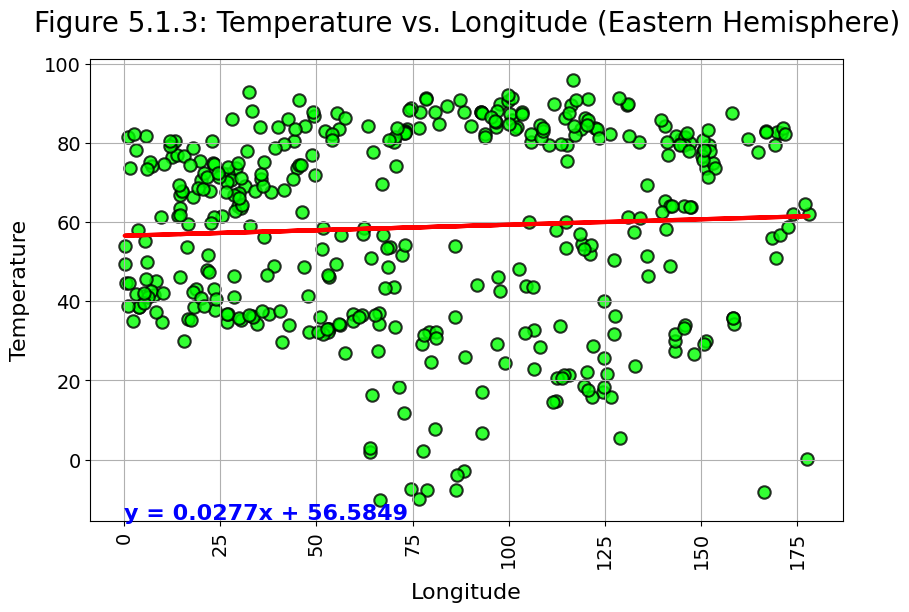

In [48]:
matplotlibx.set_regr_eqn_coords(0.0, -15.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['longitude'], 
      eastern_df['temperature']],
     'Figure 5.1.3: Temperature vs. Longitude (Eastern Hemisphere)')

 ### Display Temperature vs. Longitude (Western Hemisphere)

r-value:     0.0386
r-squared:   0.0015



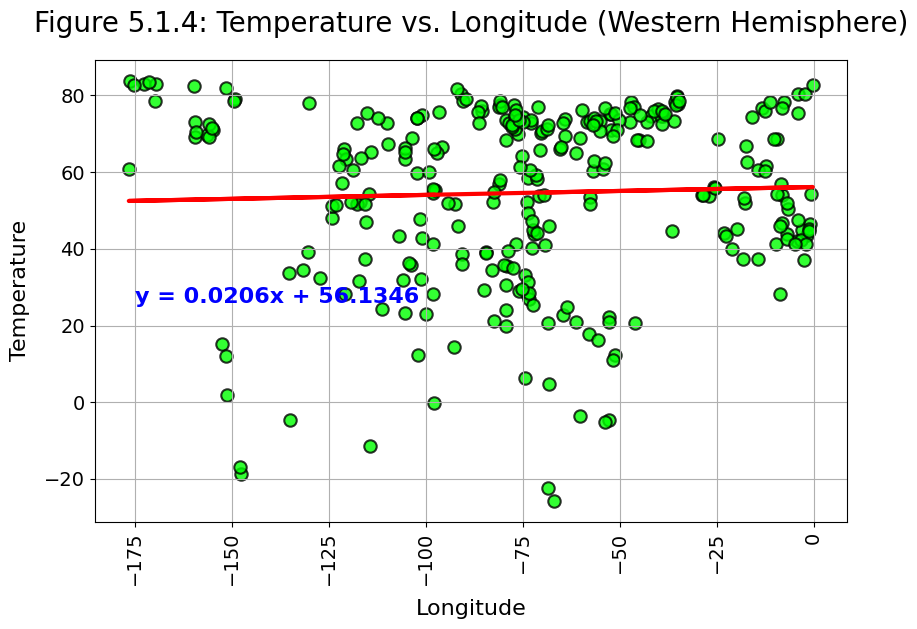

In [49]:
matplotlibx.set_regr_eqn_coords(-175.0, 26.0)

matplotlibx.scatterplot_chart \
    ([western_df['longitude'], 
      western_df['temperature']],
     'Figure 5.1.4: Temperature vs. Longitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### According to these scatter plots and regression lines, there is only a very weak relationship between longitude and temperature in any hemisphere.

## **5.2: Humidity vs. Longitude**

### **Display Humidity vs. Longitude (Northern Hemisphere)**

r-value:     -0.1635
r-squared:   0.0267



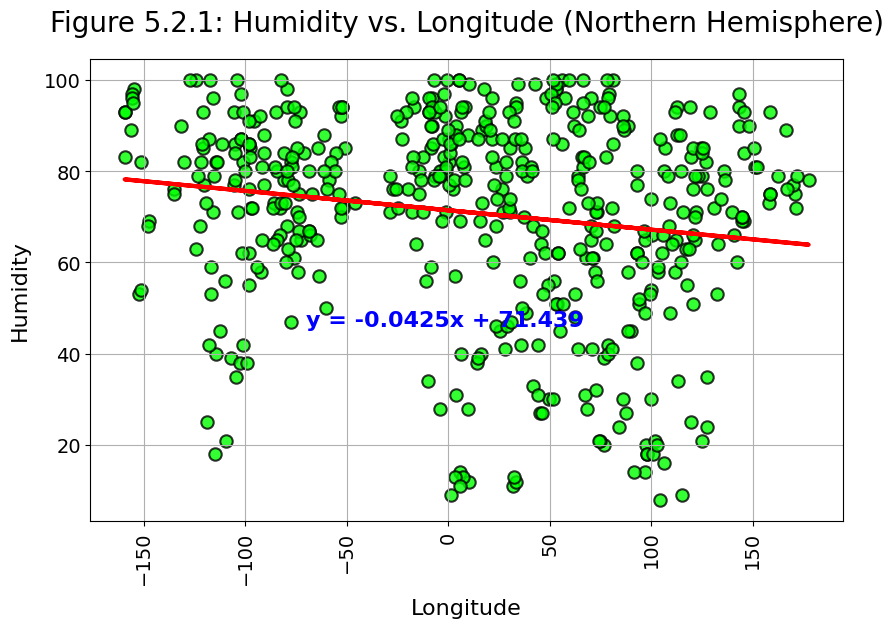

In [50]:
matplotlibx.set_scatterplot_chart_xylabels('Longitude', 'Humidity')

matplotlibx.set_regr_eqn_coords(-70.0, 46.0)


matplotlibx.scatterplot_chart \
    ([northern_df['longitude'], 
      northern_df['humidity']],
     'Figure 5.2.1: Humidity vs. Longitude (Northern Hemisphere)')

### **Display Humidity vs. Longitude (Southern Hemisphere)**

r-value:     -0.2647
r-squared:   0.0701



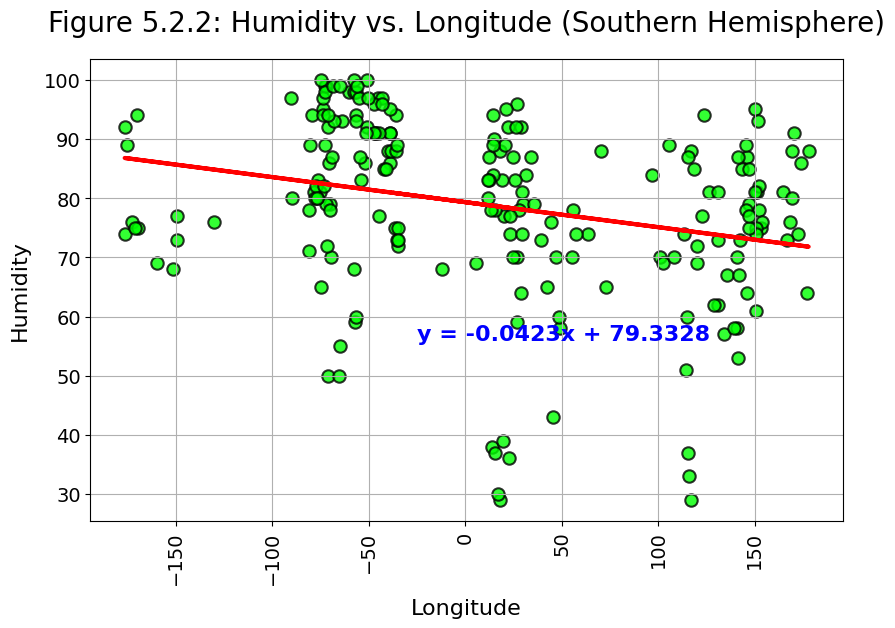

In [51]:
matplotlibx.set_regr_eqn_coords(-25.0, 56.0)

matplotlibx.scatterplot_chart \
    ([southern_df['longitude'], 
      southern_df['humidity']],
     'Figure 5.2.2: Humidity vs. Longitude (Southern Hemisphere)')

### **Display Humidity vs. Longitude (Eastern Hemisphere)**

r-value:     0.0411
r-squared:   0.0017



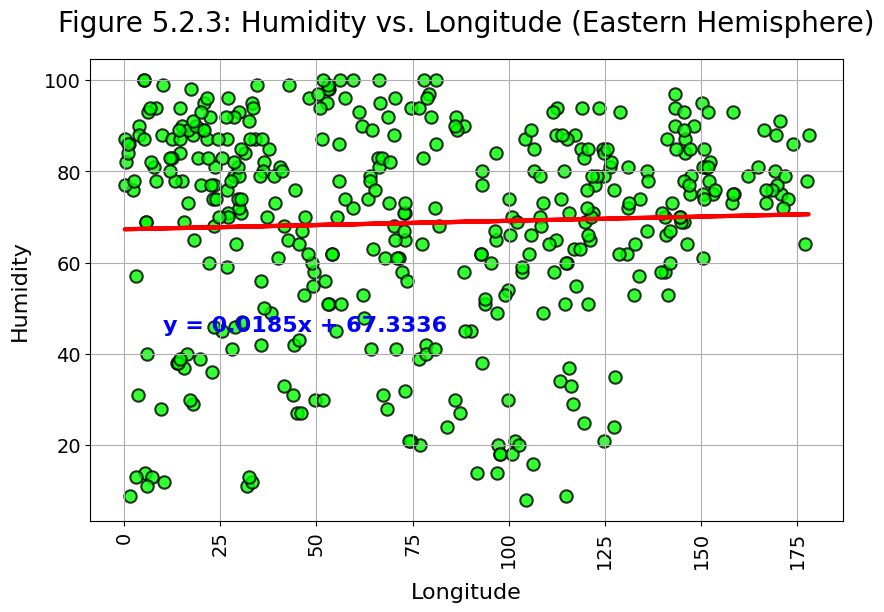

In [52]:
matplotlibx.set_regr_eqn_coords(10.0, 45.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['longitude'], 
      eastern_df['humidity']],
     'Figure 5.2.3: Humidity vs. Longitude (Eastern Hemisphere)')

### **Display Humidity vs. Longitude (Western Hemisphere)**

r-value:     0.1403
r-squared:   0.0197



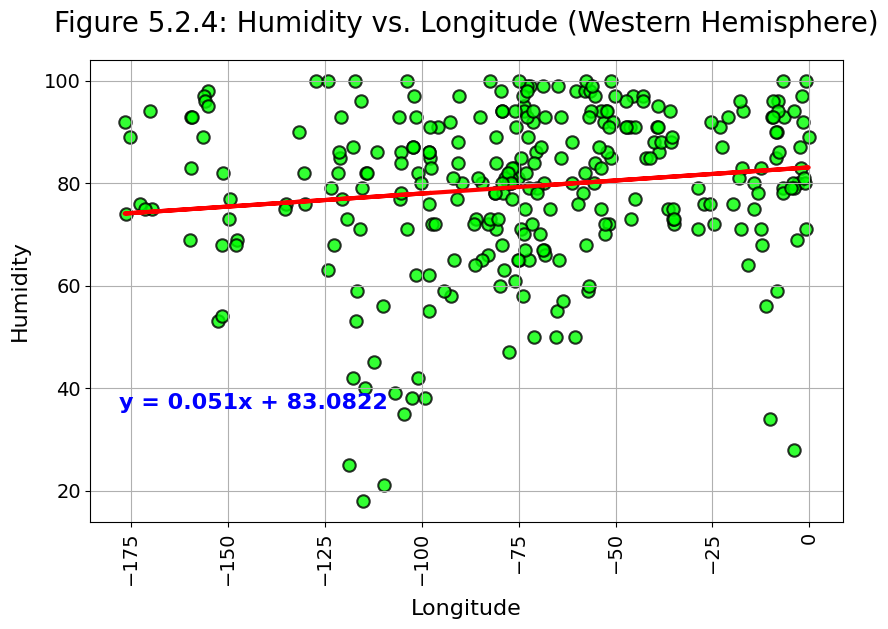

In [53]:
matplotlibx.set_regr_eqn_coords(-178.0, 36.0)

matplotlibx.scatterplot_chart \
    ([western_df['longitude'], 
      western_df['humidity']],
     'Figure 5.2.4: Humidity vs. Longitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### According to these scatter plots and regression lines, there is only a very weak relationship between longitude and humidity in any hemisphere.

## **5.3: Cloudiness vs. Longitude**

### **Display Cloudiness vs. Longitude (Northern Hemisphere)**

r-value:     0.1555
r-squared:   0.0242



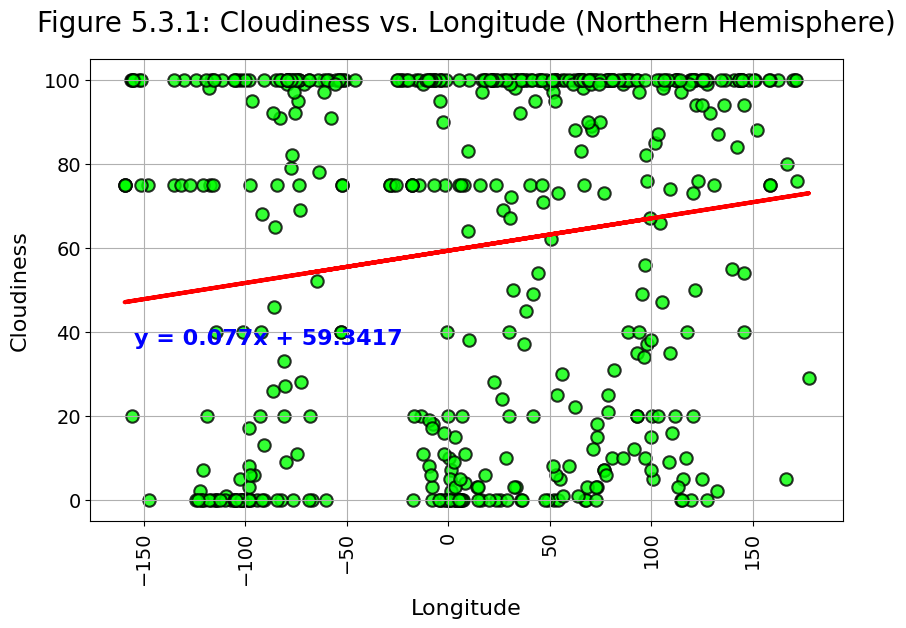

In [54]:
matplotlibx.set_scatterplot_chart_xylabels('Longitude', 'Cloudiness')

matplotlibx.set_regr_eqn_coords(-155.0, 37.0)


matplotlibx.scatterplot_chart \
    ([northern_df['longitude'], 
      northern_df['cloudiness']],
     'Figure 5.3.1: Cloudiness vs. Longitude (Northern Hemisphere)')

### **Display Cloudiness vs. Longitude (Southern Hemisphere)**

r-value:     0.1555
r-squared:   0.0242



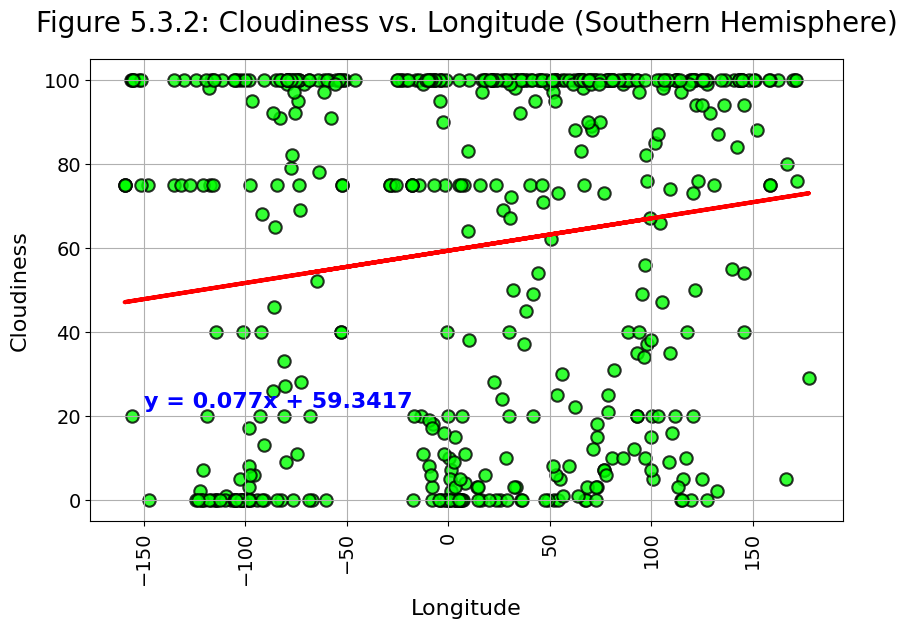

In [55]:
matplotlibx.set_regr_eqn_coords(-150.0, 22.0)

matplotlibx.scatterplot_chart \
    ([northern_df['longitude'], 
      northern_df['cloudiness']],
     'Figure 5.3.2: Cloudiness vs. Longitude (Southern Hemisphere)')

### **Display Cloudiness vs. Longitude (Eastern Hemisphere)**

r-value:     0.2364
r-squared:   0.0559



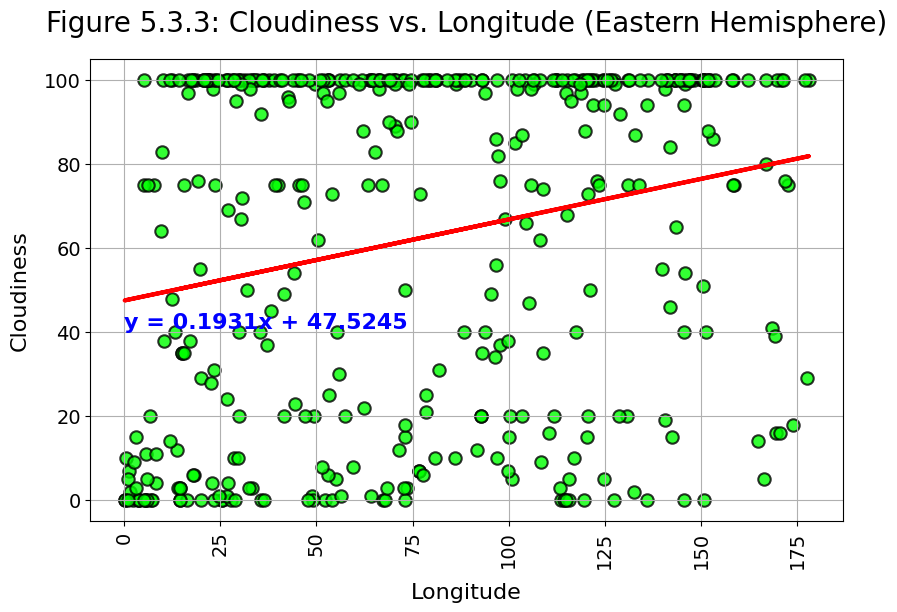

In [56]:
matplotlibx.set_regr_eqn_coords(0.0, 41.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['longitude'], 
      eastern_df['cloudiness']],
     'Figure 5.3.3: Cloudiness vs. Longitude (Eastern Hemisphere)')

### **Display Cloudiness vs. Longitude (Western Hemisphere)**

r-value:     0.1452
r-squared:   0.0211



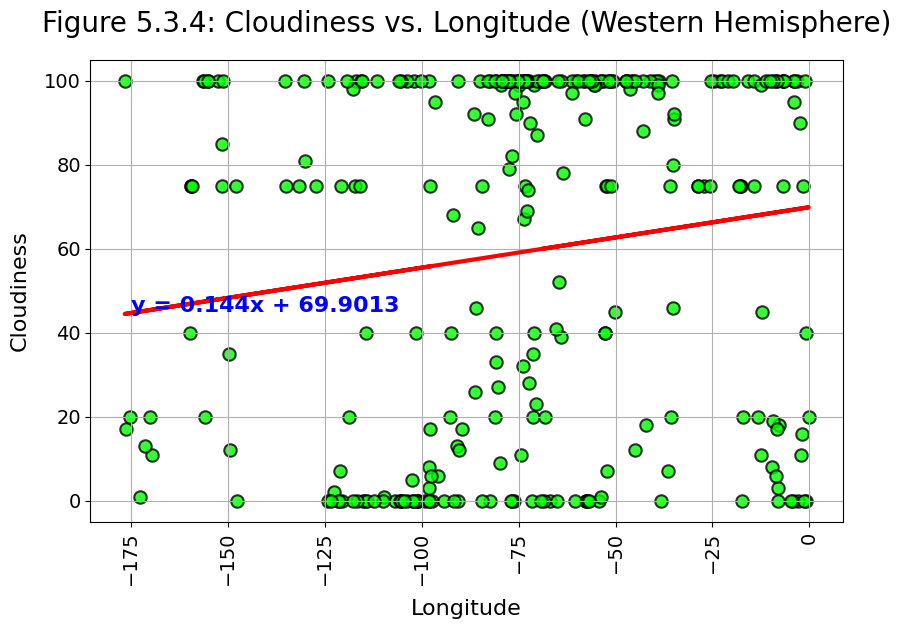

In [57]:
matplotlibx.set_regr_eqn_coords(-175.0, 45.0)

matplotlibx.scatterplot_chart \
    ([western_df['longitude'], western_df['cloudiness']],
     'Figure 5.3.4: Cloudiness vs. Longitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### According to these scatter plots and regression lines, there is only a very weak relationship between longitude and cloudiness in any hemisphere.

## **5.4: Wind Speed vs. Longitude**

### **Display Wind Speed vs. Longitude (Northern Hemisphere)**

r-value:     0.1598
r-squared:   0.0255



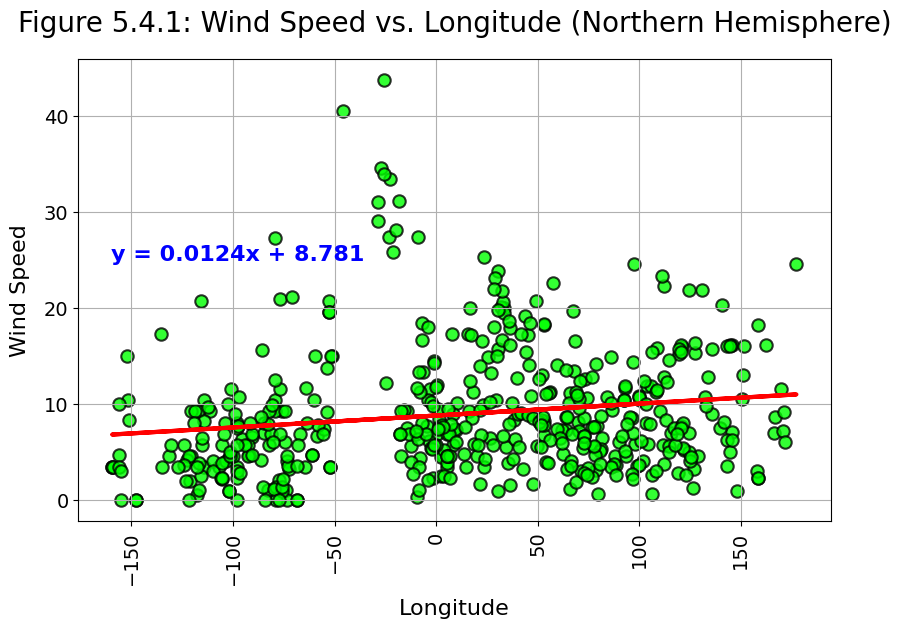

In [58]:
matplotlibx.set_scatterplot_chart_xylabels('Longitude', 'Wind Speed')

matplotlibx.set_regr_eqn_coords(-160.0, 25.0)


matplotlibx.scatterplot_chart \
    ([northern_df['longitude'], 
      northern_df['wind_speed']],
     'Figure 5.4.1: Wind Speed vs. Longitude (Northern Hemisphere)')

### **Display Wind Speed vs. Longitude (Southern Hemisphere)**

r-value:     0.2052
r-squared:   0.0421



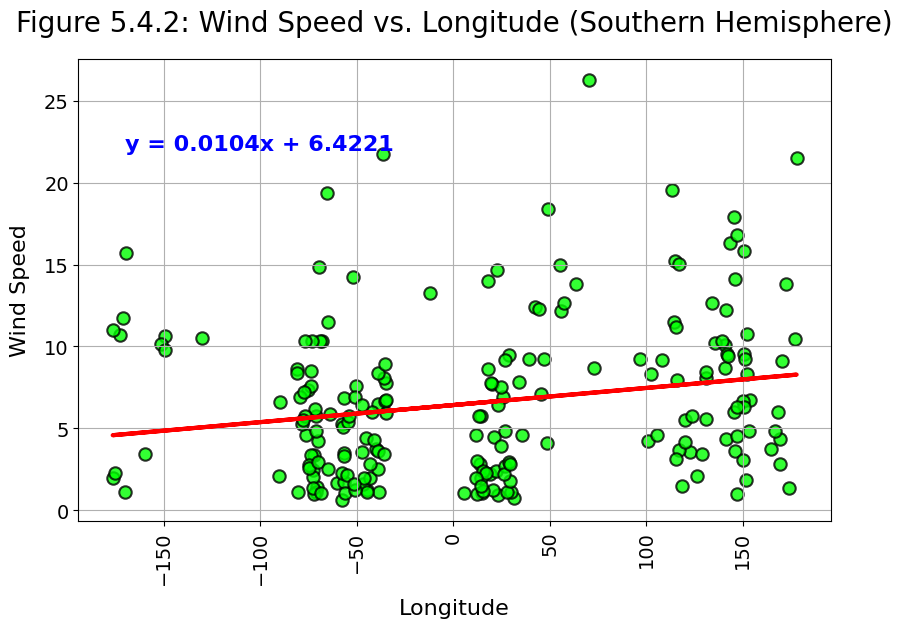

In [59]:
matplotlibx.set_regr_eqn_coords(-170.0, 22.0)

matplotlibx.scatterplot_chart \
    ([southern_df['longitude'], 
      southern_df['wind_speed']],
     'Figure 5.4.2: Wind Speed vs. Longitude (Southern Hemisphere)')

### **Display Wind Speed vs. Longitude (Eastern Hemisphere)**

r-value:     0.0601
r-squared:   0.0036



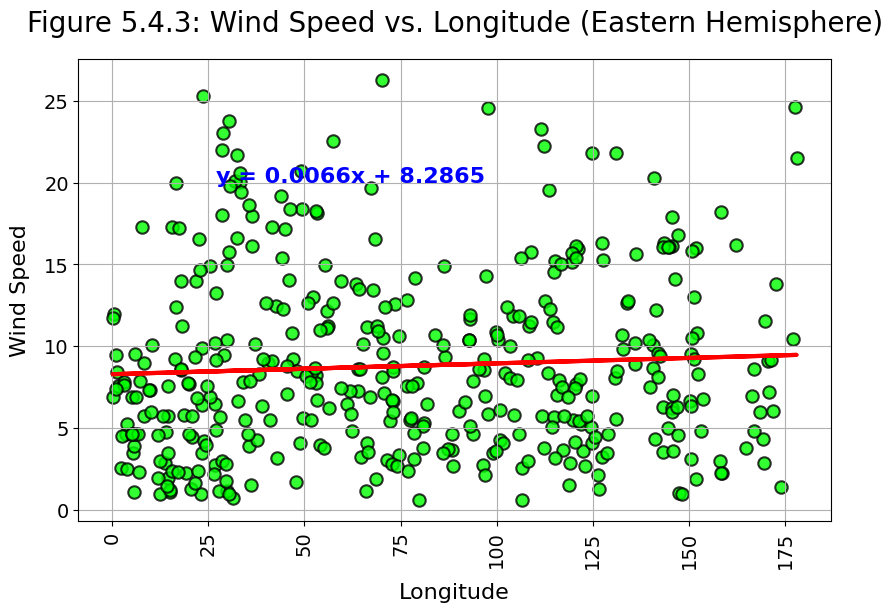

In [60]:
matplotlibx.set_regr_eqn_coords(27.0, 20.0)

matplotlibx.scatterplot_chart \
    ([eastern_df['longitude'], 
      eastern_df['wind_speed']],
     'Figure 5.4.3: Wind Speed vs. Longitude (Eastern Hemisphere)')

### **Display Wind Speed vs. Longitude (Western Hemisphere)**

r-value:     0.2484
r-squared:   0.0617



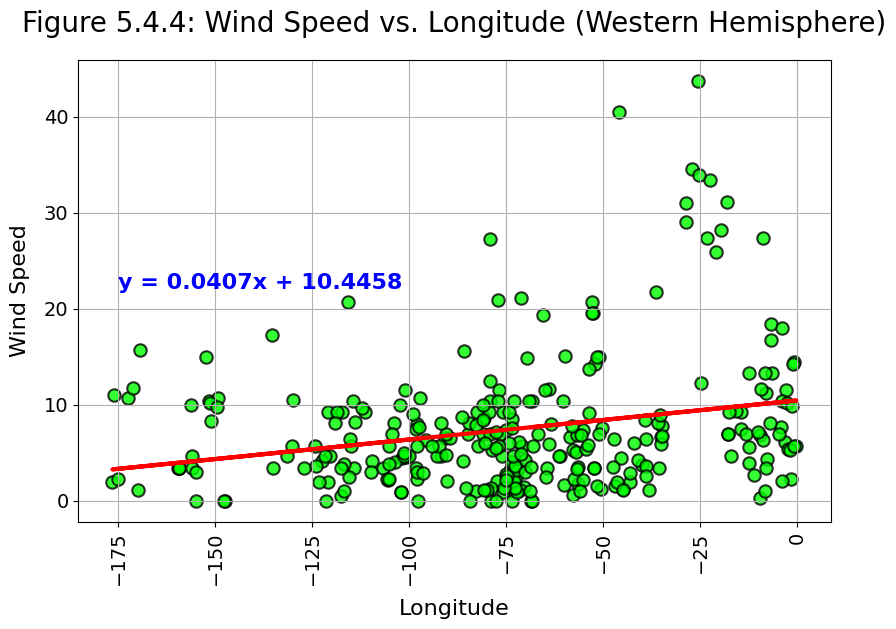

In [61]:
matplotlibx.set_regr_eqn_coords(-175.0, 22.0)

matplotlibx.scatterplot_chart \
    ([western_df['longitude'], 
      western_df['wind_speed']],
     'Figure 5.4.4: Wind Speed vs. Longitude (Western Hemisphere)')

## **Discussion about the linear relationship:** 
### According to these scatter plots and regression lines, there is only a very weak relationship between longitude and wind speed in any hemisphere.

In [62]:
# logx.end_program()